## 调用一些基本的库，必须是pyth12 环境下

In [1]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.patches as patches
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

## 导入 数据分析包 process， 以及 run_id, 数据路径等参数信息

In [21]:
from waveform_analysis.core.context import Context

from waveform_analysis.core.processing.dtypes import create_record_dtype

run_id = "00292"
ctx = Context(storage_dir="/mnt/data/TPC/run_R8520/")

from waveform_analysis.core.plugins.plugin_sets import (
    plugins_basic_features, 
    plugins_events,
    plugins_io,
    plugins_peaks,
    plugins_tabular,
    plugins_waveform,
)

ctx.register(*plugins_io())
ctx.register(*plugins_waveform())
ctx.register(*plugins_basic_features())
ctx.register(*plugins_peaks())
ctx.register(*plugins_events())
ctx.register(*plugins_tabular())


In [22]:
# ctx.show_config()

In [4]:
ctx.key_for(run_id, 'records')

'00292-records-c155b8eb'

## 定义 data process 配置参数等

In [23]:
ctx.set_config({
    "data_root": "/mnt/data/TPC/run_R8520/",
    "run_config_path": "/mnt/data/TPC/run6_Xe/run_config.json",
    # "custom_config_json_path": "run5_process.json",
    "daq_adapter": "v1725",  # 文件名包含 @VX2730，需要适配器
    "show_progress": True,
    "use_filtered": False,
    "wave_source": "records",
})
# ctx.get_plugin("st_waveforms").save_when = "always"
# ctx.set_config({"records_part_size": 25000000, "channel_workers": 1, "n_jobs": 64}, "records")
ctx.set_config(
    {
        "channel_workers": 14,
        "n_jobs": 14,
        "v1725_part_size": 20_000,
        "use_process_pool": True,
        "channel_executor": "process",
        "keep_on_disk": True,
    },
    plugin_name="records",
)
ctx.set_config({"area_range": (0, None), "height_range": (0, None)}, "basic_features")
ctx.set_config(
    {
        "asymmetry_cut_min": 0.7,
        "asymmetry_chunk_size": 200_000,
        "asymmetry_num_threads": 128,
    },
    "records_asymmetry_mask",
)
ctx.set_config(
    config={"threshold": 30, "asymmetry_cut_enabled": True, "right_extension": 5}, plugin_name="hit_threshold"
)
ctx.set_config({"merge_gap_ns": 400, "max_total_width_ns": 40000}, "hit_merged")
ctx.set_config(
    {
        "time_window_ns": 200.0,
        "max_total_width_ns": 50000.0,
        "dt": 4,
    },
    "peaklets",
)

In [24]:
print(f"/mnt/data/TPC/run6_Xe/{run_id}/runinfo.json")

/mnt/data/TPC/run6_Xe/00292/runinfo.json


In [25]:
# ctx.plot_lineage('basic_features',verbose=2)

In [26]:
# ctx.plot_lineage( "hit_merged")

In [27]:
# ctx.get_data(run_id, "hit_threshold")

In [28]:
ctx.get_data(run_id, "raw_files")

[+] Running plugin: raw_files (run_id: 00292)


[['/mnt/data/TPC/run_R8520/00292/RAW/run_R8520_20260626_174446_00292_raw_b0_seg0.bin',
  '/mnt/data/TPC/run_R8520/00292/RAW/run_R8520_20260626_174446_00292_raw_b0_seg1.bin']]

In [29]:
ctx.set_config({"records_part_size":25000000,
             "channel_workers":10,
             "n_jobs":64},"records")
# ctx.show_config("records")

## 读取原始波形数据

In [30]:
from waveform_analysis.core import records_view

rv = records_view(ctx, run_id)

records = rv.records      # 你看到的 memmap
wave_pool = rv.wave_pool  # 真正的连续波形池

def get_wave(i: int):
    off = int(records["wave_offset"][i])
    n = int(records["event_length"][i])
    w = wave_pool[off:off+n]          # 1D view (uint16)    
    return w.view("i2")

[+] Running plugin: records (run_id: 00292)


Building V1725 records:   0%|          | 0/2 [00:00<?, ?it/s]

Building V1725 records: 100%|██████████| 2/2 [01:46<00:00, 54.75s/it]

[Records 合并入口] 分片数=1191, batch_size=50, n_workers=64, executor=process
[Records 合并] records-only batch merge, 模式=并行, executor=process, workers=64, 批次数=24, 分片数=1191


[Records 合并] records-only final sort merge, 分片数=24
[Records 合并] wave_pool concat, 分片数=1191, samples=597209470


[+] Running plugin: wave_pool (run_id: 00292)


In [13]:
print(records.dtype.names)

('timestamp', 'pid', 'board', 'channel', 'baseline', 'baseline_upstream', 'polarity', 'record_id', 'dt', 'trigger_type', 'flags', 'wave_offset', 'event_length', 'time')


## 将数据类型 records存为 DataFrame 格式

In [31]:
pd.DataFrame(ctx.get_data(run_id, "records")[:3])

,timestamp,pid,board,channel,baseline,baseline_upstream,polarity,record_id,dt,trigger_type,flags,wave_offset,event_length,time
0,151240000,0,0,2,15025.0,NaN,unknown,0,4,0,0,0,50,151240
1,263012000,0,0,4,15081.0,NaN,unknown,1,4,0,0,50,50,263012
2,266468000,0,0,4,15081.0,NaN,unknown,2,4,0,0,100,50,266468


In [476]:
# ctx.get_data(run_id, "records")["channel"]

### 分析波形极限抖动情况，并打印直方图

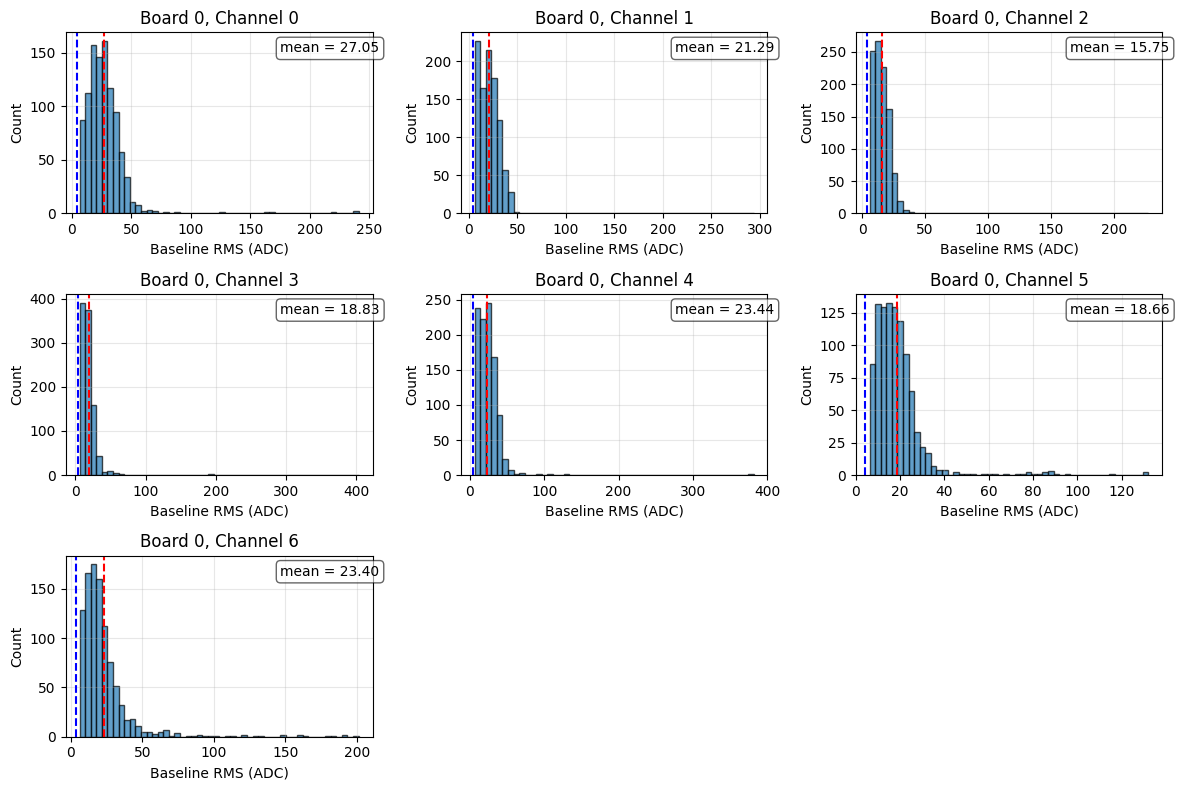

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# 固定参数
board = 0
channels = list(range(0, 7))   # board 0 的通道 9~15
n_waveforms = 1000              # 每个通道使用的波形数量
n_pre_samples = 30              # 计算 RMS 所用的起始点数

# 存储每个通道的 RMS 列表
rms_per_channel = {ch: [] for ch in channels}

for ch in channels:
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"][:n_waveforms]
    signals = rv.signals(select_runid)
    
    for i in range(signals.shape[0]):
        segment = signals[i, :n_pre_samples]   # 前30个点
        rms_val = np.std(segment)             # 标准差作为 RMS
        rms_per_channel[ch].append(rms_val)

# 绘图：3x3 子图，只使用前 7 个，隐藏后 2 个
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, ch in enumerate(channels):
    ax = axes[idx]
    rms_vals = rms_per_channel[ch]
    mean_rms = np.mean(rms_vals)          # 计算均值（中心值）
    
    # 绘制直方图
    ax.hist(rms_vals, bins=50, alpha=0.7, edgecolor='black', label='RMS distribution')
    # 添加均值垂直线
    ax.axvline(mean_rms, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_rms:.2f}')
    ax.axvline(4, color='blue', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Board 0, Channel {ch}")
    ax.set_xlabel("Baseline RMS (ADC)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    # 可选择使用对数纵轴（若分布范围宽）
    # ax.set_yscale('log')
    
    # 在右上角显示均值文本（不依赖图例）
    ax.text(0.7, 0.95, f'mean = {mean_rms:.2f}', transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
    # 可选：添加图例（如果希望同时显示线和标签）
    # ax.legend(loc='upper left')

# 隐藏多余子图
for idx in range(len(channels), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 计算、分析波形数据的非对称性，用于噪声排除； 每个通道只查看1000个原始波形

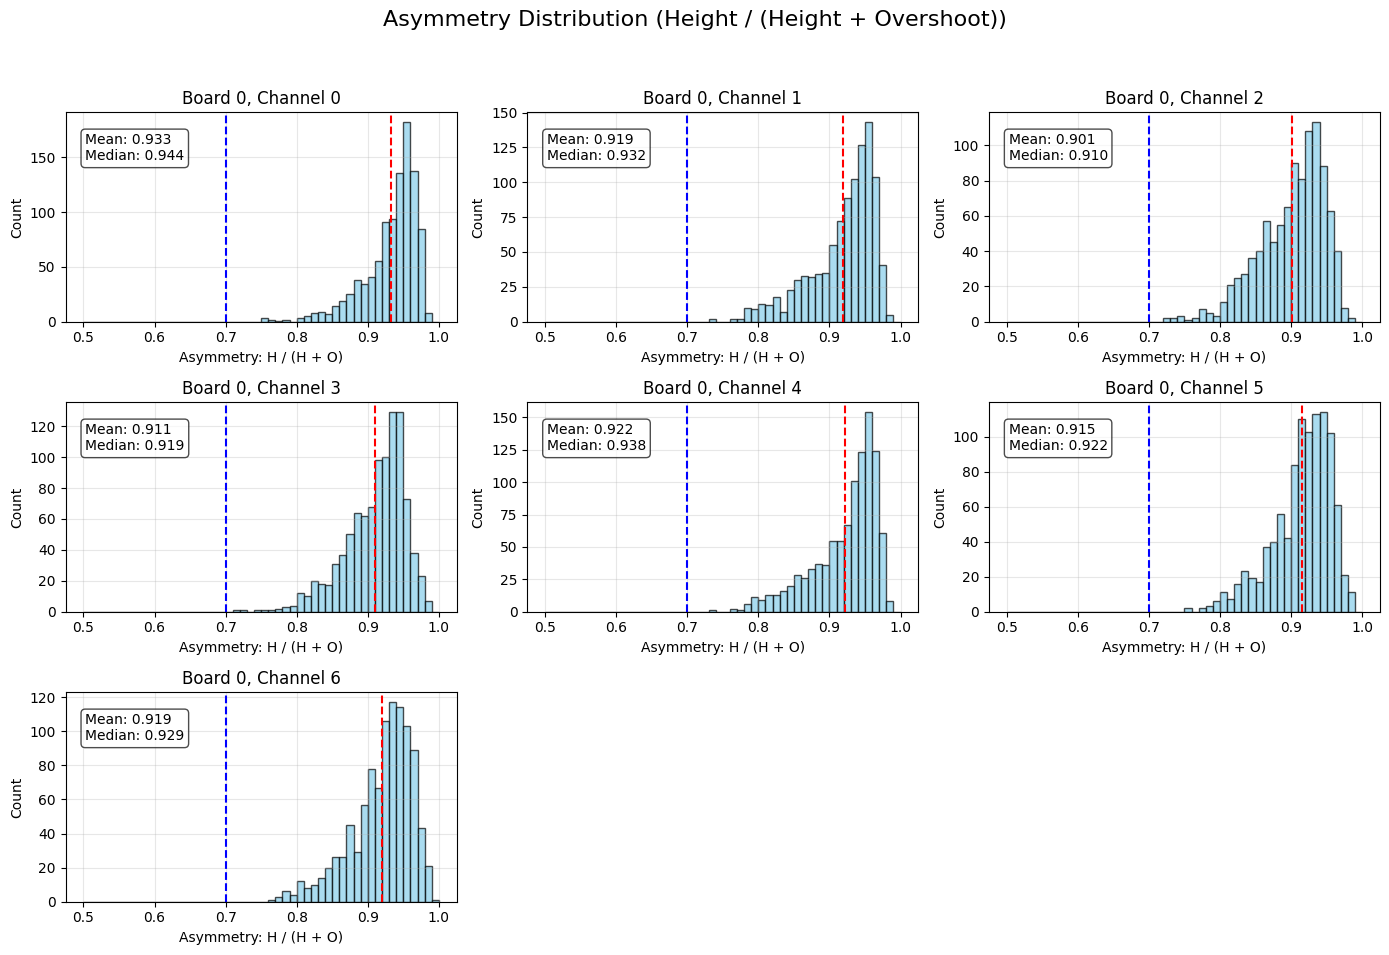

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 固定参数
board = 0
channels = list(range(0, 7))   # board 0 的通道 9~15
n_waveforms = 1000              # 每个通道使用的波形数量

# 存储每个通道的 Asymmetry 列表
asym_per_channel = {ch: [] for ch in channels}

for ch in channels:
    # 1. 获取 record_id
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"][:n_waveforms]
    
    # 2. 获取波形数据 (假设 rv.signals 已经做了基线扣除，基线在 0 附近)
    # 如果 rv.signals 没有扣基线，请确保使用带有 baseline_correct=True 的方法
    signals = rv.signals(select_runid)
    
    for i in range(signals.shape[0]):
        wave = signals[i]
        
        # --- 计算 Asymmetry ---
        # 假设信号是负脉冲：
        # Height 是向下的峰（最小值），Overshoot 是向上的回弹（最大值）
        height = abs(np.min(wave))
        overshoot = np.max(wave)
        
        # 防止分母为 0 的简单处理
        if (height + overshoot) > 0:
            asym = height / (height + overshoot)
            asym_per_channel[ch].append(asym)
        else:
            asym_per_channel[ch].append(np.nan)

# 绘图：3x3 子图
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, ch in enumerate(channels):
    ax = axes[idx]
    # 过滤掉可能的 nan 值
    data = [x for x in asym_per_channel[ch] if not np.isnan(x)]
    
    if len(data) > 0:
        mean_asym = np.mean(data)
        median_asym = np.median(data)
        
        # 绘制直方图 (Asymmetry 范围通常在 0 到 1 之间)
        ax.hist(data, bins=50, range=(0.5, 1.0), color='skyblue', alpha=0.7, edgecolor='black')
        
        # 添加均值垂直线
        ax.axvline(mean_asym, color='red', linestyle='--', linewidth=1.5)
        ax.axvline(0.7, color='blue', linestyle='--', linewidth=1.5)
        # 标注文本
        ax.text(0.05, 0.9, f'Mean: {mean_asym:.3f}\nMedian: {median_asym:.3f}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.set_title(f"Board 0, Channel {ch}")
    ax.set_xlabel("Asymmetry: H / (H + O)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

# 隐藏多余子图
for idx in range(len(channels), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Asymmetry Distribution (Height / (Height + Overshoot))", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 计算取数时长

In [42]:
print(f"Time Max: {records['time'].max()}, Time Min: {records['time'].min()}")
daq_time_length= (records['time'].max()- records['time'].min())*1.E-9
daq_time_length

Time Max: 599990984848, Time Min: 151240


np.float64(599.990833608)

## 计算 dark count rate； 每个通道，所有符合筛选条件的

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 固定参数
board = 0
channels = list(range(0, 7))   # board 0 的通道 0~6

# ---------- 计算 DAQ 总时长（秒） ----------
time_min = records['time'].min()
time_max = records['time'].max()
daq_time_length = (time_max - time_min) * 1e-9
print(f"DAQ 总时长: {daq_time_length:.3f} 秒")

asym_per_channel = {ch: [] for ch in channels}
gt_threshold_count = {ch: 0 for ch in channels}

for ch in channels:
    # ---------- 修改点：去掉切片限制，获取全部 record_id ----------
    select_runid = records[(records['channel'] == ch) & (records['board'] == board)]["record_id"]
    
    signals = rv.signals(select_runid)   # 加载全部波形
    
    for i in range(signals.shape[0]):
        wave = signals[i]
        height = abs(np.min(wave))
        overshoot = np.max(wave)
        
        if (height + overshoot) > 0:
            asym = height / (height + overshoot)
            asym_per_channel[ch].append(asym)
            if asym > 0.7:
                gt_threshold_count[ch] += 1
        else:
            asym_per_channel[ch].append(np.nan)

# 打印 DCR 结果...
# 绘图部分不变...

DAQ 总时长: 599.991 秒


###  打印每个通道的 dark count rate,以及非对称性参数分布直方图


暗计数率 (Dark Count Rate) 计算结果：
定义：Asymmetry > 0.7 的事件数 / DAQ 总时长
Channel  0 : 有效波形 285608 个 | 超过阈值事件 285580 个 | DCR =   475.97 Hz
Channel  1 : 有效波形 7501445 个 | 超过阈值事件 7500947 个 | DCR = 12501.77 Hz
Channel  2 : 有效波形 465111 个 | 超过阈值事件 465025 个 | DCR =   775.05 Hz
Channel  3 : 有效波形  87442 个 | 超过阈值事件  87436 个 | DCR =   145.73 Hz
Channel  4 : 有效波形 3061936 个 | 超过阈值事件 3061540 个 | DCR =  5102.64 Hz
Channel  5 : 有效波形 297568 个 | 超过阈值事件 297562 个 | DCR =   495.94 Hz
Channel  6 : 有效波形 208289 个 | 超过阈值事件 208274 个 | DCR =   347.13 Hz


/tmp/ipykernel_1578813/3205413224.py:66: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_1578813/3205413224.py:66: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipykernel_1578813/3205413224.py:66: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/home/yjj/.conda/envs/pyth12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yjj/.conda/envs/pyth12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/yjj/.conda/envs

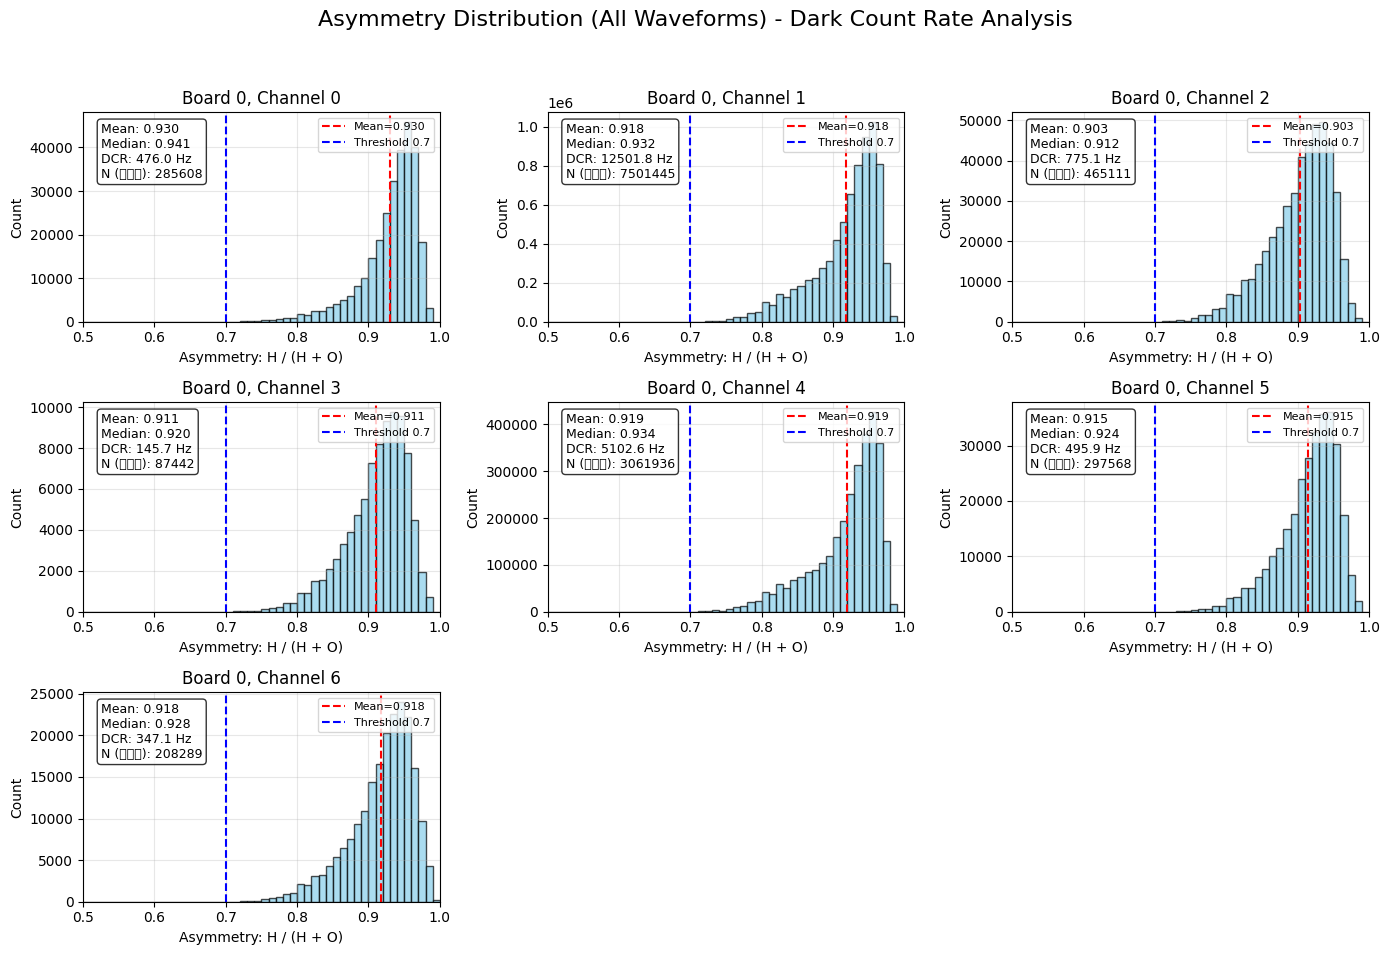

In [46]:
# ---------- 4. 输出暗计数率 (DCR) 统计结果 ----------
print("\n" + "=" * 60)
print("暗计数率 (Dark Count Rate) 计算结果：")
print("定义：Asymmetry > 0.7 的事件数 / DAQ 总时长")
print("=" * 60)

for ch in channels:
    count = gt_threshold_count[ch]
    # 过滤出有效波形数量（非 nan）
    valid_waves = [x for x in asym_per_channel[ch] if not np.isnan(x)]
    total_valid = len(valid_waves)
    
    # 计算暗计数率 (Hz)
    dcr = count / daq_time_length if daq_time_length > 0 else 0
    
    print(f"Channel {ch:2d} : 有效波形 {total_valid:6d} 个 | 超过阈值事件 {count:6d} 个 | DCR = {dcr:8.2f} Hz")

# ---------- 5. 绘制 3x3 子图直方图 ----------
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, ch in enumerate(channels):
    ax = axes[idx]
    
    # 过滤掉 nan 值，只保留有效数据
    data = [x for x in asym_per_channel[ch] if not np.isnan(x)]
    
    if len(data) > 0:
        mean_asym = np.mean(data)
        median_asym = np.median(data)
        dcr = gt_threshold_count[ch] / daq_time_length if daq_time_length > 0 else 0
        
        # 绘制直方图 (Asymmetry 物理范围通常在 0~1 之间，此处聚焦 0.5~1.0)
        ax.hist(data, bins=50, range=(0.5, 1.0), color='skyblue', alpha=0.7, edgecolor='black')
        
        # 标注均值线（红色虚线）和阈值线 0.7（蓝色虚线）
        ax.axvline(mean_asym, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_asym:.3f}')
        ax.axvline(0.7, color='blue', linestyle='--', linewidth=1.5, label='Threshold 0.7')
        
        # 在左上角添加统计信息文本框
        text_str = (
            f'Mean: {mean_asym:.3f}\n'
            f'Median: {median_asym:.3f}\n'
            f'DCR: {dcr:.1f} Hz\n'
            f'N (总波形): {len(data)}'
        )
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.legend(loc='upper right', fontsize=8)
    else:
        # 无数据通道显示提示
        ax.text(0.5, 0.5, 'No Valid Data', ha='center', va='center', transform=ax.transAxes)
    
    ax.set_title(f"Board {board}, Channel {ch}")
    ax.set_xlabel("Asymmetry: H / (H + O)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, 1.0)  # 固定 x 轴范围便于比较

# 隐藏多余的子图（channels 只有 7 个，但 subplot 是 3x3=9 个）
for idx in range(len(channels), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Asymmetry Distribution (All Waveforms) - Dark Count Rate Analysis", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
